# Notebook Objective

The objective of this notebook is to create meaningful features from the cleaned dataset wherever possible. These engineered features will enhance exploratory analysis, support SQL-based business reporting, and prepare the dataset for potential machine learning applications.

## 1. Load Clean Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/creditcard_clean.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Transaction Amount Categories

### Business Questions

- How can transaction amounts be grouped into meaningful business categories?

In [2]:
bins = [0, 10, 50, 100, np.inf]

labels = [
    "Small",
    "Medium",
    "Large",
    "Very Large"
]

df["Amount_Category"] = pd.cut(
    df["Amount"],
    bins=bins,
    labels=labels
)

In [3]:
df["Amount_Category"].value_counts()

Amount_Category
Small         98013
Medium        90327
Very Large    56399
Large         37179
Name: count, dtype: int64

## Analysis

- Transaction amounts have been grouped into business-friendly categories to simplify reporting and dashboard visualizations.
- The transaction amount thresholds were manually defined for reporting purposes, as the dataset does not provide business-specific categorization rules. 
- These categories make it easier to analyze fraud patterns across different transaction value ranges.

## 3. Log Transformed Amount

### Business Questions

- How can the highly skewed transaction amount distribution be transformed to better support future analytical and predictive tasks?

In [4]:
df["Log_Amount"] = np.log1p(df["Amount"])

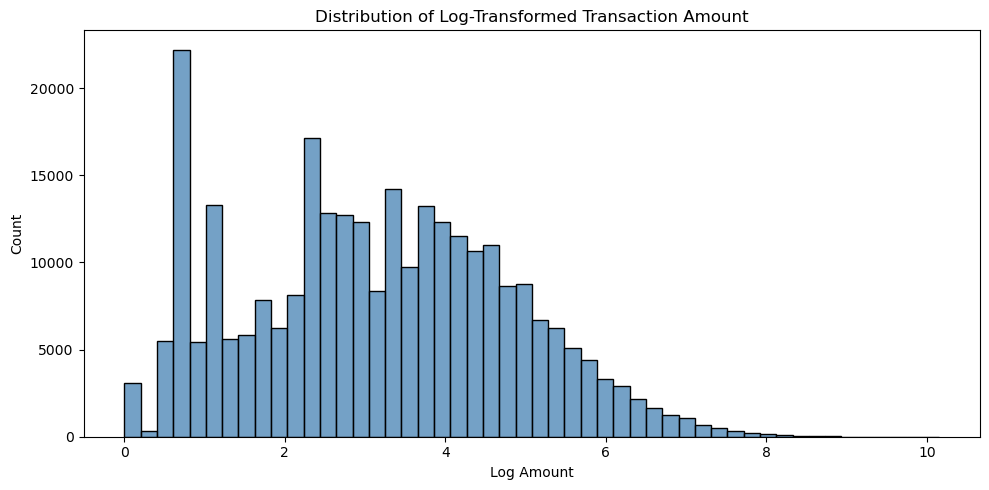

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Log_Amount",
    bins=50,
    color="steelblue"
)

plt.title("Distribution of Log-Transformed Transaction Amount")
plt.xlabel("Log Amount")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Analysis

- Applying a logarithmic transformation reduces the effect of extremely large transaction amounts and produces a more balanced distribution.
- This engineered feature is particularly useful for machine learning algorithms that are sensitive to highly skewed data.

## 4. Exporting the Engineered Dataset

In [6]:
df.to_csv(
    "../data/processed/creditcard_engineered.csv",
    index=False
)

# Key Takeaways

- Created business-friendly transaction amount categories.
- Applied logarithmic transformation to reduce skewness in transaction amounts.
- Preserved the original features while adding engineered variables.
- Saved the engineered dataset for SQL analysis and future predictive modeling.